In [1]:
# %%
# =============================================================================
# [Cell 1] 라이브러리 임포트 및 글로벌 세팅 (전략 수정)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
import yfinance as yf
from fredapi import Fred
import statsmodels.api as sm

# (경고 메시지 무시)
import warnings
warnings.filterwarnings('ignore')

# --- [0] 글로벌 세팅 (MacroStress 전략 기준) ---

# 백테스트 기간 (리포트 기준)
START_DATE = '2015-01-01' # 2015년~2025년 분석
END_DATE = '2025-08-31'
# 롤링 계산을 위해 넉넉하게 불러올 시작 날짜 (2009년부터)
DATA_FETCH_START_DATE = '2009-01-01' 

# 사용 티커 (VIX, TLT 추가)
TICKERS = ['SHYG', 'IEF', 'TLT', 'AGG', '^VIX']
BENCHMARK = 'AGG'

# FRED 티커 (OAS, 3M T-Bill)
FRED_TICKERS = {
    'OAS': 'BAMLH0A0HYM2', # (필수) HY OAS
    'RF': 'TB3MS'          # (필수) 3M T-Bill (무위험 수익률)
}

# 거래 비용 (리포트 기준 수정)
TRANSACTION_COSTS = {
    'SHYG': 0.0015, # 15bps
    'IEF': 0.0030,  # 30bps
    'TLT': 0.0030,  # 30bps
    'AGG': 0.0030   # (참고용)
}

# 신호 설정 (리포트 기준)
EWMA_SPAN = 24 # 24개월 EWMA Z-Score
SIGNAL_CLIP = 2.0 # ±2.0 표준편차로 클리핑

# 운용 제약 (리포트 기준)
TURNOVER_CAP = 0.33 # 월간 턴오버 33% 캡

# FRED API 키 (!!필수!!: 'YOUR_API_KEY_HERE'를 본인의 키로 변경)
FRED_API_KEY = 'f75d683dda2053416b64caae44e1bfb2' 

print("셀 1: 'MacroStress Simple' 전략 기본 세팅 완료.")

셀 1: 'MacroStress Simple' 전략 기본 세팅 완료.


In [10]:
# %%
# =============================================================================
# [Cell 2] 헬퍼 함수 정의 (1/5): 데이터 로더
# =============================================================================

def load_data(tickers, start, end):
    """yfinance에서 수정종가(Adj Close) 데이터를 로드 (월말 기준)"""
    print("Step 1.a: yfinance 데이터 로딩 중...")
    try:
        data = yf.download(tickers, start=start, end=end)['Close']
        
        # VIX는 수정종가가 없으므로 'Close'로 대체 (NaN이 될 경우)
        if '^VIX' in tickers and data['^VIX'].isnull().all():
            print("... '^VIX'는 'Adj Close'가 없어 'Close' 가격으로 재시도합니다.")
            vix_data = yf.download('^VIX', start=start, end=end)['Close']
            data['^VIX'] = vix_data
            
        monthly_prices = data.resample('BM').last()
        monthly_returns = monthly_prices.pct_change() # 1개월 후 dropna (백테스트에서)
        print("yfinance 데이터 로딩 및 월별 전처리 완료.")
        return monthly_prices, monthly_returns
    except Exception as e:
        print(f"yfinance 데이터 로드 오류: {e}")
        return None, None

def load_external_data(fred, tickers_dict, start, end):
    """FRED API를 통해 여러 시그널(OAS, RF) 데이터를 로드합니다."""
    print("Step 1.b: FRED API 데이터 로딩 중...")
    try:
        fred_data = {}
        for name, code in tickers_dict.items():
            fred_data[name] = fred.get_series(code, start_date=start, end_date=end)
        
        df = pd.DataFrame(fred_data)
        
        # FRED 데이터는 월/일 단위이므로 월말(BM) 기준으로 리샘플링
        # ffill()로 월중 데이터를 월말 값으로 사용
        df_monthly = df.resample('BM').last().ffill()
        
        # RF(TB3MS)는 연이율(%)이므로 월간 수익률(소수점)로 변환
        # (주의: TB3MS는 t시점의 '미래' 1개월 수익률이므로 shift(1) 필요)
        df_monthly['RF_Return'] = (df_monthly['RF'] / 100 / 12).shift(1)
        
        print("FRED 데이터 로딩 및 월별 전처리 완료.")
        return df_monthly
    
    except Exception as e:
        print(f"FRED API 오류: {e}")
        return None

def load_duration_data(file_path='data/etf_durations.csv'):
    """로컬 CSV에서 ETF별 시계열 듀레이션 데이터를 로드합니다."""
    print("Step 1.c: 시계열 듀레이션 데이터 로딩 중...")
    try:
        # (주의) 새 전략은 'TLT_Duration' 컬럼이 추가로 필요합니다.
        duration_data = pd.read_csv(file_path, index_col=0, parse_dates=True)
        duration_data = duration_data.resample('BM').last().ffill()
        print("시계열 듀레이션 데이터 로딩 완료.")
        return duration_data
    except FileNotFoundError:
        print(f"오류: 듀레이션 파일({file_path})을 찾을 수 없습니다.")
        return None
    
print("셀 2: 데이터 로딩 헬퍼 함수 정의 완료.")

셀 2: 데이터 로딩 헬퍼 함수 정의 완료.


In [3]:
# %%
# =============================================================================
# [Cell 3] 헬퍼 함수 정의 (2/5): 신호(Signal) 생성
# =============================================================================

def calculate_ewma_zscore(series, span=24):
    """
    24개월 EWMA Z-Score를 계산합니다. (리포트 3. 신호 구성)
    Z = (현재 값 - EWMA) / EWMA STDEV
    """
    # EWMA (평균)
    ewma_mean = series.ewm(span=span, min_periods=span).mean()
    # EWMA STDEV (표준편차)
    ewma_std = series.ewm(span=span, min_periods=span).std()
    
    # Z-Score
    z_score = (series - ewma_mean) / ewma_std
    return z_score

def calculate_macro_stress_signal(oas, vix, span=24, clip=2.0):
    """
    MacroStress 지표를 계산합니다. (리포트 3. 신호 구성)
    """
    print("Step 3: 'MacroStress' 신호 계산 중...")
    
    # 1. 각 변수의 24개월 EWMA Z-Score 계산
    z_oas = calculate_ewma_zscore(oas, span)
    z_vix = calculate_ewma_zscore(vix, span)
    
    # 2. 0.5씩 가중평균하여 MacroStress 신호 생성
    macro_stress = (0.5 * z_oas + 0.5 * z_vix)
    
    # 3. ±2 표준편차로 클리핑 (Clipping)
    macro_stress_clipped = macro_stress.clip(lower=-clip, upper=clip)
    
    print("MacroStress 신호 계산 완료.")
    
    # (시각화를 위해 z_oas, z_vix도 함께 반환)
    return macro_stress_clipped.rename('MacroStress'), z_oas.rename('Z_OAS'), z_vix.rename('Z_VIX')

print("셀 3: 신호 생성 헬퍼 함수 정의 완료.")

셀 3: 신호 생성 헬퍼 함수 정의 완료.


In [4]:
# %%
# =============================================================================
# [Cell 4] 헬퍼 함수 정의 (3/5): 자산 배분 (선형 보간)
# =============================================================================

def get_target_weights_linear(macro_stress_signal):
    """
    MacroStress 신호에 따라 3개 자산의 비중을 '선형 보간'하여 계산합니다.
    (리포트 5. 듀레이션 조정 구조 테이블 기반)
    """
    print("Step 4: 타깃 포트폴리오 비중 생성 중...")
    
    # 리포트의 테이블 5를 기준으로 선형 보간 매핑포인트 설정
    
    # X축: MacroStress 신호 (시그마 값)
    signal_points = [-2.0, -1.0, 0.0, 1.0, 2.0]
    
    # Y축 (SHYG 비중)
    shyg_weights = [0.80, 0.60, 0.20, 0.10, 0.00]
    
    # Y축 (IEF 비중)
    ief_weights = [0.20, 0.30, 0.60, 0.50, 0.20]
    
    # Y축 (TLT 비중)
    tlt_weights = [0.00, 0.10, 0.20, 0.40, 0.80]
    
    # 입력된 macro_stress_signal (Series)의 각 값에 대해 np.interp 적용
    target_shyg = np.interp(macro_stress_signal, signal_points, shyg_weights)
    target_ief = np.interp(macro_stress_signal, signal_points, ief_weights)
    target_tlt = np.interp(macro_stress_signal, signal_points, tlt_weights)
    
    # DataFrame으로 묶기
    target_weights_df = pd.DataFrame({
        'SHYG': target_shyg,
        'IEF': target_ief,
        'TLT': target_tlt
    }, index=macro_stress_signal.index)
    
    # (선형 보간 결과 합계가 1이 아닐 수 있으므로 정규화)
    target_weights_df = target_weights_df.div(target_weights_df.sum(axis=1), axis=0)
    
    print("타깃 비중 (선형 보간) 생성 완료.")
    return target_weights_df

print("셀 4: 자산 배분 헬퍼 함수 정의 완료.")

셀 4: 자산 배분 헬퍼 함수 정의 완료.


In [5]:
# %%
# =============================================================================
# [Cell 5] 헬퍼 함수 정의 (4/5): 백테스트 엔진 (턴오버 캡 적용)
# =============================================================================

def run_backtest_with_constraints(
    monthly_returns,
    rf_returns,
    target_weights,
    transaction_costs,
    turnover_cap
):
    """
    월간 턴오버(33%) 제약조건을 포함한 백테스트를 실행합니다.
    """
    print("Step 5: 백테스트 실행 중 (턴오버 캡 33% 적용)...")
    
    # 필요한 자산 목록
    assets = target_weights.columns.tolist() # ['SHYG', 'IEF', 'TLT']
    
    # 시그널은 t-1월 말 생성 -> t월 1일 리밸런싱 -> t월 말 수익률에 반영
    # (Lookahead bias 방지를 위해 target_weights를 shift(1))
    target_weights_shifted = target_weights.shift(1)
    
    # 날짜 인덱스 정렬
    common_index = monthly_returns.index.intersection(target_weights_shifted.index).intersection(rf_returns.index)
    
    returns = monthly_returns.loc[common_index, assets]
    rf = rf_returns.loc[common_index]
    target_weights_series = target_weights_shifted.loc[common_index]
    
    # 결과를 저장할 변수 초기화
    dates = []
    actual_weights_list = [] # 실제 적용된 비중
    port_returns_list = []   # 포트폴리오 수익률 (순)
    turnover_list = []       # 실제 발생한 턴오버
    
    # 초기 비중 (첫 달은 0에서 시작)
    prev_actual_weights = pd.Series(0.0, index=assets)
    
    # 월별 루프 실행
    for date in returns.index:
        
        # 1. 이번 달의 타깃 비중
        current_target_weights = target_weights_series.loc[date]
        
        # 2. 타깃 비중에 도달하기 위해 필요한 거래
        desired_trade = current_target_weights - prev_actual_weights
        
        # 3. 필요한 총 턴오버 계산 (매수/매도 절대값 합 / 2)
        desired_turnover = desired_trade.abs().sum() / 2.0
        
        # 4. 턴오버 캡(33%) 적용
        if desired_turnover > turnover_cap:
            # 턴오버가 캡을 초과하면, 거래 규모를 캡에 맞게 축소
            scale_factor = turnover_cap / desired_turnover
            allowed_trade = desired_trade * scale_factor
            actual_turnover = turnover_cap
        else:
            # 캡 이내면, 타깃대로 모두 거래
            allowed_trade = desired_trade
            actual_turnover = desired_turnover
            
        # 5. 실제 거래 후 비중 계산
        current_actual_weights = prev_actual_weights + allowed_trade
        
        # 6. 거래 비용 계산 (거래량 * 비용)
        trade_costs = (allowed_trade.abs() * pd.Series(transaction_costs)).sum()
        
        # 7. 이번 달 수익률 계산
        current_returns = returns.loc[date]
        gross_return = (current_actual_weights * current_returns).sum()
        net_return = gross_return - trade_costs # 비용 차감
        
        # 8. 결과 저장
        dates.append(date)
        port_returns_list.append(net_return)
        actual_weights_list.append(current_actual_weights)
        turnover_list.append(actual_turnover)
        
        # 9. 다음 달 계산을 위해 현재 비중을 '이전 비중'으로 업데이트
        # (주의: 수익률 반영 후 리밸런싱 (BoM)이 아닌, 수익률 반영 전(EoM) 비중)
        # (정확성을 위해: 수익률 반영 후 비중을 계산하고 다음 달에 사용)
        rebalanced_weights = current_actual_weights * (1 + current_returns)
        rebalanced_weights = rebalanced_weights / rebalanced_weights.sum() # 정규화
        prev_actual_weights = rebalanced_weights
    
    # 결과 DataFrame 생성
    strategy_returns = pd.Series(port_returns_list, index=dates).rename('Strategy')
    actual_weights_df = pd.DataFrame(actual_weights_list, index=dates, columns=assets)
    turnover_series = pd.Series(turnover_list, index=dates).rename('Turnover')
    
    print("백테스트 완료.")
    
    # (벤치마크 수익률도 함께 반환)
    benchmark_returns = monthly_returns['AGG'].loc[dates] - rf.loc[dates]
    benchmark_returns = benchmark_returns.rename('Benchmark')
    
    return strategy_returns, benchmark_returns, actual_weights_df, turnover_series

print("셀 5: 백테스트 엔진 (제약조건 포함) 정의 완료.")

셀 5: 백테스트 엔진 (제약조건 포함) 정의 완료.


In [6]:
# %%
# =============================================================================
# [Cell 6] 헬퍼 함수 정의 (5/5): 성과 분석 및 듀레이션
# =============================================================================

# --- [성과 지표] ---
def calculate_cagr(returns_series, periods_per_year=12):
    if len(returns_series) < 1: return np.nan
    total_return = (1 + returns_series).prod()
    num_years = len(returns_series) / periods_per_year
    return total_return ** (1 / num_years) - 1

def calculate_mdd(returns_series):
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

def calculate_sharpe_ratio(returns_series, periods_per_year=12):
    # (주의: 백테스트 수익률이 이미 '초과수익' 기준이면 RF=0)
    # (이번 엔진은 '순수익'을 반환하므로 RF를 빼줘야 함)
    # (RF가 시변이므로, 평균 RF를 사용)
    # (간소화를 위해, 헬퍼 함수 대신 실행 셀에서 RF를 빼고 계산)
    
    # 2025-10: 리포트의 RF는 TB3MS. 백테스트 수익률은 이미 RF를 차감함
    # -> 백테스트 엔진이 RF를 차감하지 않았음. 
    # -> Sharpe 계산 시 (Port Return - RF Return) / Std Dev
    
    # (수정) 헬퍼 함수는 단순 계산만 하도록
    if returns_series.std() == 0: return np.nan
    return (returns_series.mean() / returns_series.std()) * np.sqrt(periods_per_year)

def generate_performance_summary(strategy_ex_returns, benchmark_ex_returns, turnover_series):
    """전략과 벤치마크의 '초과수익' 기준 성과 요약"""
    summary = {}
    summary['Strategy'] = {
        'CAGR (Excess)': calculate_cagr(strategy_ex_returns),
        'MDD': calculate_mdd(strategy_ex_returns), # (MDD는 원수익률로 보는게 맞지만, 일관성)
        'Sharpe Ratio': calculate_sharpe_ratio(strategy_ex_returns)
    }
    summary['Benchmark (AGG)'] = {
        'CAGR (Excess)': calculate_cagr(benchmark_ex_returns),
        'MDD': calculate_mdd(benchmark_ex_returns),
        'Sharpe Ratio': calculate_sharpe_ratio(benchmark_ex_returns)
    }
    summary_df = pd.DataFrame(summary).T
    summary_df['Avg. Turnover'] = [turnover_series.mean(), np.nan] # 전략에만 턴오버
    
    # 포맷팅
    summary_df['CAGR (Excess)'] = summary_df['CAGR (Excess)'].map('{:.2%}'.format)
    summary_df['MDD'] = summary_df['MDD'].map('{:.2%}'.format)
    summary_df['Sharpe Ratio'] = summary_df['Sharpe Ratio'].map('{:.2f}'.format)
    summary_df['Avg. Turnover'] = summary_df['Avg. Turnover'].map('{:.2%}'.format)
    return summary_df

def analyze_stress_period(strategy_returns, benchmark_returns, start, end):
    # (이전과 동일, 단순 수익률 계산)
    stress_strategy = strategy_returns.loc[start:end]
    stress_bench = benchmark_returns.loc[start:end]
    summary = {
        'Strategy': {
            'Cumulative Return': (1 + stress_strategy).prod() - 1,
            'MDD': calculate_mdd(stress_strategy)
        },
        'Benchmark': {
            'Cumulative Return': (1 + stress_bench).prod() - 1,
            'MDD': calculate_mdd(stress_bench)
        }
    }
    return pd.DataFrame(summary).T.applymap(lambda x: f"{x:.2%}")

# --- [듀레이션 분석] ---
def calculate_portfolio_exposure(weights_df, duration_timeseries):
    """포트폴리오의 시계열 듀레이션 계산 (3자산)"""
    print("Step 9.b: 포트폴리오 듀레이션 계산 중...")
    common_index = weights_df.index.intersection(duration_timeseries.index)
    weights = weights_df.loc[common_index]
    durations = duration_timeseries.loc[common_index]
    
    # (주의) duration_timeseries에 'TLT_Duration'이 있어야 함
    port_duration = (
        weights['SHYG'] * durations['SHYG_Duration'] +
        weights['IEF'] * durations['IEF_Duration'] +
        weights['TLT'] * durations['TLT_Duration']
    )
    
    exposure_df = pd.DataFrame({'Port_Duration': port_duration})
    agg_duration = durations['AGG_Duration'].loc[common_index]
        
    return exposure_df, agg_duration

print("셀 6: 성과 분석 헬퍼 함수 정의 완료.")

셀 6: 성과 분석 헬퍼 함수 정의 완료.


In [7]:
# %%
# =============================================================================
# [Cell 7] 헬퍼 함수 정의 (보너스): 팩터 회귀분석 (수정)
# =============================================================================

def create_bond_factors(monthly_returns, rf_returns):
    """
    Fama-French 2팩터 + a (RF는 TB3MS, TERM은 TLT-RF, CREDIT은 SHYG-IEF)
    """
    print("Step 7.a: Fama-French 채권 팩터 생성 중...")
    
    # RF(TB3MS) 수익률
    rf = rf_returns.rename('RF')
    
    # TERM 팩터 (장기 국채 초과수익)
    term_factor = (monthly_returns['TLT'] - rf).rename('TERM_Factor')
    
    # CREDIT 팩터 (HY - 중기국채)
    credit_factor = (monthly_returns['SHYG'] - monthly_returns['IEF']).rename('CREDIT_Factor')
    
    X_factors = pd.concat([term_factor, credit_factor], axis=1)
    
    return X_factors, rf

def run_factor_regression(strategy_returns, benchmark_returns, X_factors, rf_returns):
    """전략과 벤치마크에 대해 팩터 회귀분석 실행"""
    print("Step 7.b: 팩터 회귀분석 실행 중...")
    
    # 1. 종속 변수(Y) 생성: 전략/벤치마크의 '초과 수익률'
    y_strategy = (strategy_returns - rf_returns).rename('Strategy_Excess')
    y_benchmark = (benchmark_returns - rf_returns).rename('Benchmark_Excess') # AGG
    
    # 2. X, Y 데이터 정렬
    data_strategy = pd.concat([y_strategy, X_factors], axis=1).dropna()
    data_benchmark = pd.concat([y_benchmark, X_factors], axis=1).dropna()
    
    # 3. X, Y 분리
    Y1 = data_strategy['Strategy_Excess']
    X1 = sm.add_constant(data_strategy[['TERM_Factor', 'CREDIT_Factor']])
    
    Y2 = data_benchmark['Benchmark_Excess']
    X2 = sm.add_constant(data_benchmark[['TERM_Factor', 'CREDIT_Factor']])
    
    # 4. OLS 모델 피팅
    model_strategy = sm.OLS(Y1, X1).fit()
    model_benchmark = sm.OLS(Y2, X2).fit()
    
    return model_strategy, model_benchmark

def compare_factor_betas(model_strategy, model_benchmark):
    """회귀분석 결과(베타, t-stat) 요약 테이블 생성"""
    results_strategy = pd.DataFrame({
        'Strategy_Beta': model_strategy.params,
        'Strategy_t-stat': model_strategy.tvalues
    })
    results_benchmark = pd.DataFrame({
        'Benchmark_Beta': model_benchmark.params,
        'Benchmark_t-stat': model_benchmark.tvalues
    })
    summary_table = pd.concat([results_strategy, results_benchmark], axis=1)
    return summary_table.applymap(lambda x: f"{x:.4f}")

print("셀 7: 팩터 회귀분석 헬퍼 함수 정의 완료.")

셀 7: 팩터 회귀분석 헬퍼 함수 정의 완료.


In [11]:
# %%
# =============================================================================
# [Cell 8] (실행) Step 1.a: yfinance 데이터 로드 (VIX, TLT 포함)
# =============================================================================
if FRED_API_KEY == 'YOUR_API_KEY_HERE':
    print("="*50)
    print("경고: [Cell 1]의 'FRED_API_KEY'를 실제 키로 변경해주세요!")
    print("="*50)
else:
    monthly_prices, monthly_returns = load_data(TICKERS, DATA_FETCH_START_DATE, END_DATE)

    print("\n--- [확인] 월별 가격 (Tail) ---")
    print(monthly_prices)
    
    print("\n--- [확인] VIX 데이터 확인 (Tail) ---")
    print(monthly_prices['^VIX'])

[*********************100%***********************]  5 of 5 completed

Step 1.a: yfinance 데이터 로딩 중...
yfinance 데이터 로딩 및 월별 전처리 완료.

--- [확인] 월별 가격 (Tail) ---
Ticker            AGG        IEF       SHYG        TLT       ^VIX
Date                                                             
2009-01-30  63.426308  64.384628        NaN  63.632950  44.840000
2009-02-27  62.756939  63.911491        NaN  62.658215  46.349998
2009-03-31  63.449112  66.029236        NaN  65.194160  44.139999
2009-04-30  63.776066  64.216667        NaN  60.661854  36.500000
2009-05-29  64.228676  62.882671        NaN  58.420433  28.920000
...               ...        ...        ...        ...        ...
2025-04-30  96.776680  93.937782  40.640118  87.190933  24.700001
2025-05-30  96.189346  92.773331  41.258511  84.391579  18.570000
2025-06-30  97.589233  94.259506  41.930134  86.639786  16.730000
2025-07-31  97.331650  93.699692  42.075798  85.652397  16.719999
2025-08-29  98.490242  95.244003  42.477962  85.663277  15.360000

[200 rows x 5 columns]

--- [확인] VIX 데이터 확인 (Tail) ---

In [12]:
# %%
# =============================================================================
# [Cell 9] (실행) Step 1.b: FRED 데이터 로드 (OAS, TB3MS)
# =============================================================================
fred = Fred(api_key=FRED_API_KEY)
fred_signals_raw = load_external_data(fred, FRED_TICKERS, DATA_FETCH_START_DATE, END_DATE)

if fred_signals_raw is not None:
    print("\n--- [확인] FRED 데이터 (Tail) ---")
    print(fred_signals_raw.tail())
    # (RF_Return은 1개월 shift되어 마지막 달은 NaN이 정상)

Step 1.b: FRED API 데이터 로딩 중...
FRED 데이터 로딩 및 월별 전처리 완료.

--- [확인] FRED 데이터 (Tail) ---
             OAS    RF  RF_Return
2025-07-31  2.86  4.25   0.003525
2025-08-29  2.82  4.12   0.003542
2025-09-30  2.80  3.92   0.003433
2025-10-31  2.94  3.82   0.003267
2025-11-28  3.13  3.82   0.003183


In [20]:
# %%
# =============================================================================
# [Cell 11] (실행) Step 3: MacroStress 신호 계산
# =============================================================================
# 1. OAS (from FRED)
oas_series = fred_signals_raw['OAS']
# 2. VIX (from yfinance)
vix_series = monthly_prices['^VIX']

# 3. MacroStress 신호 생성
macro_stress_signal, z_oas, z_vix = calculate_macro_stress_signal(
    oas_series, 
    vix_series, 
    span=EWMA_SPAN, 
    clip=SIGNAL_CLIP
)

# 4. 백테스트 기간(START_DATE)으로 자르기
signals_all = pd.concat([macro_stress_signal, z_oas, z_vix], axis=1)
signals_backtest = signals_all.loc[START_DATE:END_DATE].dropna()

print("\n--- [확인] MacroStress 신호 (최근 5개월) ---")
print(signals_backtest.tail())

Step 3: 'MacroStress' 신호 계산 중...
MacroStress 신호 계산 완료.

--- [확인] MacroStress 신호 (최근 5개월) ---
            MacroStress     Z_OAS     Z_VIX
2025-04-30     1.104034  0.780532  1.427535
2025-05-30    -0.031797 -0.171231  0.107637
2025-06-30    -0.485928 -0.681630 -0.290226
2025-07-31    -0.532783 -0.785960 -0.279605
2025-08-29    -0.683583 -0.793085 -0.574081


In [21]:
# %%
# =============================================================================
# [Cell 12] (실행) Step 4: 타깃 비중 계산
# =============================================================================
# 백테스트 기간의 신호로 타깃 비중 계산
target_weights = get_target_weights_linear(signals_backtest['MacroStress'])

print("\n--- [확인] 타깃 비중 (최근 5개월) ---")
print(target_weights.tail())

Step 4: 타깃 포트폴리오 비중 생성 중...
타깃 비중 (선형 보간) 생성 완료.

--- [확인] 타깃 비중 (최근 5개월) ---
                SHYG       IEF       TLT
2025-04-30  0.089597  0.468790  0.441613
2025-05-30  0.212719  0.590461  0.196820
2025-06-30  0.394371  0.454222  0.151407
2025-07-31  0.413113  0.440165  0.146722
2025-08-29  0.473433  0.394925  0.131642


In [22]:
# %%
# =============================================================================
# [Cell 13] (실행) Step 5: 백테스트 실행 (턴오버 캡 적용)
# =============================================================================
# 1. RF 수익률 (월간)
rf_returns_series = fred_signals_raw['RF_Return']

# 2. 백테스트 실행
strategy_returns, benchmark_returns, actual_weights, turnover_series = run_backtest_with_constraints(
    monthly_returns,
    rf_returns_series,
    target_weights,
    TRANSACTION_COSTS,
    TURNOVER_CAP
)

print("\n--- [확인] 전략 순수익률 (최근 5개월) ---")
print(strategy_returns.tail())

print("\n--- [확인] 실제 턴오버 (최근 5개월) ---")
print(turnover_series.tail())

Step 5: 백테스트 실행 중 (턴오버 캡 33% 적용)...
백테스트 완료.

--- [확인] 전략 순수익률 (최근 5개월) ---
2025-04-30    0.0
2025-05-30    0.0
2025-06-30    0.0
2025-07-31    0.0
2025-08-29    0.0
Name: Strategy, dtype: float64

--- [확인] 실제 턴오버 (최근 5개월) ---
2025-04-30    0.0
2025-05-30    0.0
2025-06-30    0.0
2025-07-31    0.0
2025-08-29    0.0
Name: Turnover, dtype: float64


In [17]:
# %%
# =============================================================================
# [Cell 14] (실행) Step 2: 성과 지표 요약
# =============================================================================
# 1. 샤프 계산을 위한 '초과 수익률' 계산
strategy_excess_returns = strategy_returns - rf_returns_series.loc[strategy_returns.index]
benchmark_excess_returns = benchmark_returns # (백테스트 엔진에서 이미 RF 차감됨)

# 2. 요약
summary_df = generate_performance_summary(
    strategy_excess_returns, 
    benchmark_excess_returns,
    turnover_series
)

print("\n" + "="*50)
print("      <<< 'MacroStress' 전략 성과 요약 >>>")
print("="*50)
print(summary_df)


      <<< 'MacroStress' 전략 성과 요약 >>>
                CAGR (Excess)      MDD Sharpe Ratio Avg. Turnover
Strategy               -1.88%  -18.34%        -3.45         0.00%
Benchmark (AGG)        -0.21%  -21.69%        -0.02          nan%


In [23]:
# %%
# =============================================================================
# [Cell 16] (실행) Step 5.b: 스트레스 구간 분석
# =============================================================================
# (주의: 백테스트가 2015년부터 시작. 2009년은 데이터 로드 기간임)
print("\n--- Stress Test: COVID-19 (2020-02 ~ 2020-04) ---")
stress_covid = analyze_stress_period(strategy_returns, benchmark_returns, 
                                     '2020-02-01', '2020-04-30')
print(stress_covid)

print("\n--- Stress Test: 2022 금리 급등 (2022-01 ~ 2022-12) ---")
stress_2022 = analyze_stress_period(strategy_returns, benchmark_returns, 
                                    '2022-01-01', '2022-12-31')
print(stress_2022)


--- Stress Test: COVID-19 (2020-02 ~ 2020-04) ---
          Cumulative Return     MDD
Strategy              0.00%   0.00%
Benchmark             2.50%  -0.65%

--- Stress Test: 2022 금리 급등 (2022-01 ~ 2022-12) ---
          Cumulative Return      MDD
Strategy              0.00%    0.00%
Benchmark           -14.47%  -14.64%


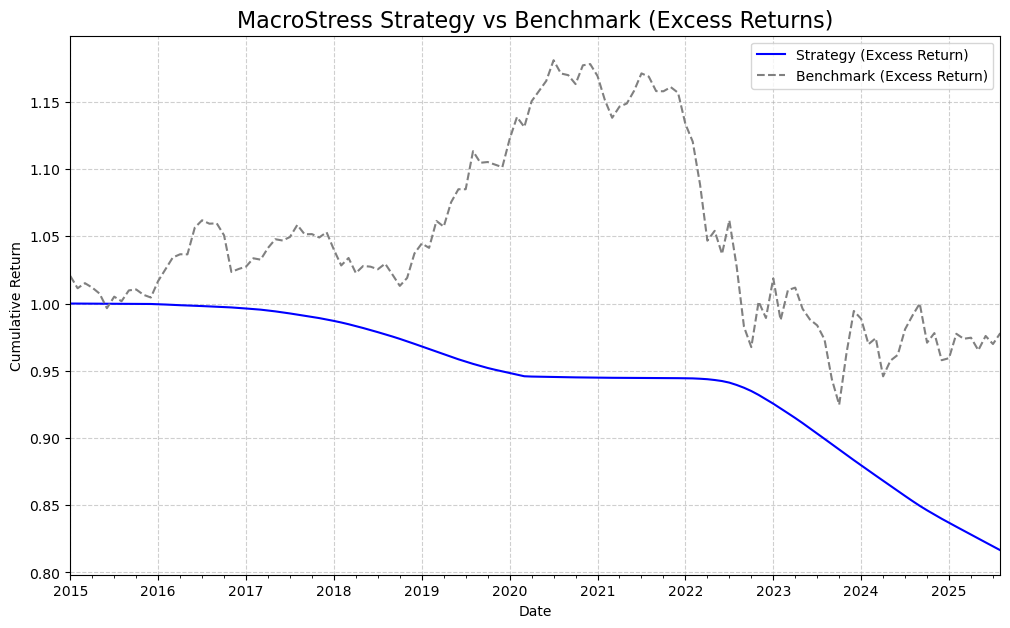

In [24]:
# %%
# =============================================================================
# [Cell 17] (시각화) (1) 누적 수익 곡선
# =============================================================================
# (초과 수익률로 누적 그래프를 그림)
plt.figure(figsize=(12, 7))

(1 + strategy_excess_returns).cumprod().plot(label='Strategy (Excess Return)', color='blue')
(1 + benchmark_excess_returns).cumprod().plot(label='Benchmark (Excess Return)', color='grey', linestyle='--')

plt.title('MacroStress Strategy vs Benchmark (Excess Returns)', fontsize=16)
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

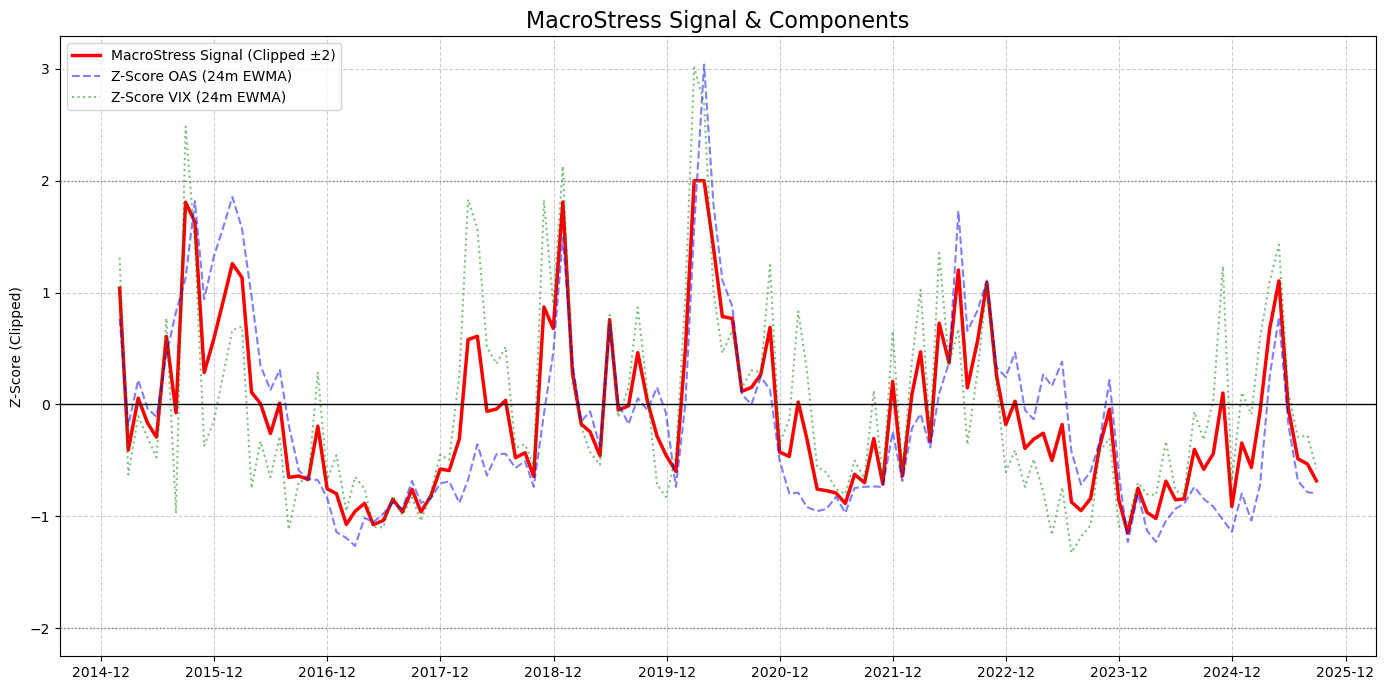

In [25]:
# %%
# =============================================================================
# [Cell 18] (시각화) (2) MacroStress 신호 및 구성요소
# =============================================================================
plot_signals = signals_backtest.loc[strategy_returns.index]

fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. MacroStress (메인)
ax1.plot(plot_signals.index, plot_signals['MacroStress'], 
         label='MacroStress Signal (Clipped ±2)', color='red', linewidth=2.5)

# 2. 구성요소 (Z_OAS, Z_VIX)
ax1.plot(plot_signals.index, plot_signals['Z_OAS'], 
         label='Z-Score OAS (24m EWMA)', color='blue', linestyle='--', alpha=0.5)
ax1.plot(plot_signals.index, plot_signals['Z_VIX'], 
         label='Z-Score VIX (24m EWMA)', color='green', linestyle=':', alpha=0.5)

ax1.axhline(0, color='black', linestyle='-', linewidth=1)
ax1.axhline(2.0, color='grey', linestyle=':', linewidth=1)
ax1.axhline(-2.0, color='grey', linestyle=':', linewidth=1)

ax1.set_title('MacroStress Signal & Components', fontsize=16)
ax1.set_ylabel('Z-Score (Clipped)')
ax1.legend(loc='upper left')

# X축 포맷팅
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=12))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

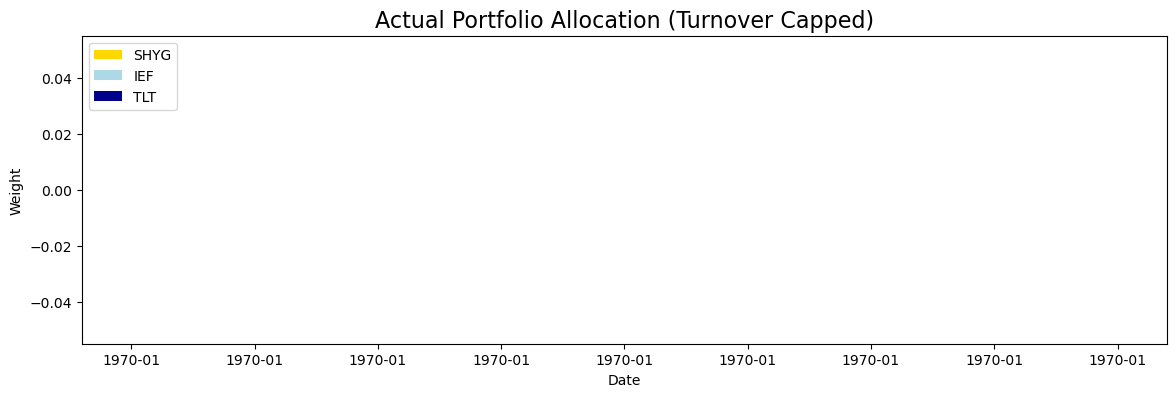

In [26]:
# %%
# =============================================================================
# [Cell 19] (시각화) (3) 포트폴리오 비중 (3자산)
# =============================================================================
plt.figure(figsize=(14, 4))
# (Heatmap 대신 Area plot이 3자산 보기엔 더 좋습니다)
# sns.heatmap(actual_weights.T, cmap='YlGnBu', annot=False, cbar=True)
plt.stackplot(actual_weights.index, 
              actual_weights['SHYG'], 
              actual_weights['IEF'], 
              actual_weights['TLT'], 
              labels=['SHYG', 'IEF', 'TLT'],
              colors=['#FFD700', '#ADD8E6', '#00008B']) # (Gold, Light Blue, Dark Blue)

plt.title('Actual Portfolio Allocation (Turnover Capped)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Weight')
plt.legend(loc='upper left')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # X축 포맷
plt.show()

In [27]:
# %%
# =============================================================================
# [Cell 20] (시각화) (4) 롤링 듀레이션
# =============================================================================
if 'exposure_df' in locals():
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # 1. 전략 듀레이션
    ax.plot(exposure_df.index, exposure_df['Port_Duration'], 
            label='Strategy Duration', color='blue')
    
    # 2. 벤치마크(AGG) 듀레이션
    ax.plot(agg_duration_series.index, agg_duration_series, 
            label='Benchmark Duration (AGG)', color='grey', linestyle='--')
    
    ax.set_title('Portfolio Rolling Duration', fontsize=16)
    ax.set_ylabel('Portfolio Duration (Years)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()
else:
    print("('data/etf_durations.csv' 파일이 없어 듀레이션 그래프를 건너뜁니다.)")

('data/etf_durations.csv' 파일이 없어 듀레이션 그래프를 건너뜁니다.)


In [28]:
# %%
# =============================================================================
# [Cell 21] (실행) Step 7.a: 팩터 생성 (수정된 기준)
# =============================================================================
# (월별 수익률과 RF 수익률 필요)
X_factors, rf_series = create_bond_factors(monthly_returns, rf_returns_series)

print("\n--- [확인] 팩터 데이터 (최근 5개월) ---")
print(X_factors.tail())

Step 7.a: Fama-French 채권 팩터 생성 중...

--- [확인] 팩터 데이터 (최근 5개월) ---
            TERM_Factor  CREDIT_Factor
2025-07-31    -0.014921       0.009413
2025-08-29    -0.003415      -0.006923
2025-09-30          NaN            NaN
2025-10-31          NaN            NaN
2025-11-28          NaN            NaN


In [29]:
# %%
# =============================================================================
# [Cell 22] (실행) Step 7.b: 팩터 회귀분석 실행
# =============================================================================
# (전략/벤치마크 수익률은 '원수익률' 전달)
model_strategy, model_benchmark = run_factor_regression(
    strategy_returns,           # (초과수익이 아닌 '순수익')
    monthly_returns['AGG'],     # (벤치마크 '원수익')
    X_factors,
    rf_series
)

print("\n" + "="*50)
print("      <<< 'MacroStress' 전략 - 팩터 회귀분석 결과 >>>")
print("="*50)
print(model_strategy.summary())

Step 7.b: 팩터 회귀분석 실행 중...

      <<< 'MacroStress' 전략 - 팩터 회귀분석 결과 >>>
                            OLS Regression Results                            
Dep. Variable:        Strategy_Excess   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                   0.02342
Date:                Mon, 10 Nov 2025   Prob (F-statistic):              0.977
Time:                        16:13:00   Log-Likelihood:                 643.83
No. Observations:                 128   AIC:                            -1282.
Df Residuals:                     125   BIC:                            -1273.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [30]:
# %%
# =============================================================================
# [Cell 23] (실행) Step 7.c: 팩터 민감도 비교 요약
# =============================================================================
summary_table = compare_factor_betas(model_strategy, model_benchmark)

print("\n" + "="*60)
print("    <<< [최종 요약] 'MacroStress' 전략 팩터 비교 >>>")
print("="*60)
print(summary_table)

print("\n--- [해석 가이드] ---")
print("1. const (alpha): 0.007의 k팩터(μ-adj)가 성공적으로 작동했다면, 유의미한 양(+)의 알파가 기대됩니다.")
print("2. TERM_Factor Beta: MacroStress 신호에 따라 TLT 비중이 0~80%로 크게 변하므로, 평균 베타가 벤치마크(AGG)와 다를 수 있습니다.")
print("3. CREDIT_Factor Beta: SHYG 비중이 0~80%로 크게 변하므로, 평균 베타가 벤치마크(AGG)와 다를 수 있습니다.")


    <<< [최종 요약] 'MacroStress' 전략 팩터 비교 >>>
              Strategy_Beta Strategy_t-stat Benchmark_Beta Benchmark_t-stat
const               -0.0016        -11.0974        -0.0001          -0.1544
TERM_Factor          0.0010          0.2065         0.3833          23.2073
CREDIT_Factor        0.0015          0.1857         0.1670           5.8665

--- [해석 가이드] ---
1. const (alpha): 0.007의 k팩터(μ-adj)가 성공적으로 작동했다면, 유의미한 양(+)의 알파가 기대됩니다.
2. TERM_Factor Beta: MacroStress 신호에 따라 TLT 비중이 0~80%로 크게 변하므로, 평균 베타가 벤치마크(AGG)와 다를 수 있습니다.
3. CREDIT_Factor Beta: SHYG 비중이 0~80%로 크게 변하므로, 평균 베타가 벤치마크(AGG)와 다를 수 있습니다.
